In [ ]:
!pip install fastai opencv-python tqdm imutils -q
!pip install wandb

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 144.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.6/208.6 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 460.9/460.9 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 7.0 MB/s eta 0:00:00


In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import cv2
import fastai
from fastai.vision.all import *
from fastai.basics import *
from fastai.callback.all import *
import imutils
import torch
import ast
from pathlib import Path
from google.colab import drive
from sklearn.model_selection import train_test_split
from fastai.callback.wandb import WandbCallback
from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback
import json
import wandb
from google.colab import userdata

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


### Connect notebook to WanDB

In [ ]:
wandb.login(
    key=userdata.get('WANDB_API_KEY')
)
wandb.init(project="Dartsify AI",name="unet_res34_optuna_finetune")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


### Load Dataset

In [ ]:
!mkdir data
!cp -v "drive/My Drive/Dartsify/dataset.zip" "data"
!unzip -q -d data data/dataset.zip

!cp -v "drive/My Drive/Dartsify/label.csv" "data"

!mkdir -p data/masks2

'drive/My Drive/Dartsify/dataset.zip' -> 'data/dataset.zip'
'drive/My Drive/Dartsify/label.csv' -> 'data/label.csv'


In [ ]:
# Lire les annotations à partir du fichier csv
# ID : nom unique de l'image
# Position : format d'un dictionnaire avec les coordonnées des points de la cible et des fléchettes
# Exemple de Position : "{'objects': {'point': {'x': x1, 'y': y1}}}"
df = pd.read_csv('data/label.csv')[['ID', 'Position']]

# Supprimer les lignes qui n'ont pas d'ID
df = df.dropna(subset=["ID"])

dataset_path = Path('data/dataset/')
mask_path = Path('data/masks2/')


df["image_path"] = df["ID"].apply(
    lambda x: dataset_path / x
)

df["mask_path"] = df["ID"].apply(
    lambda x: mask_path / x
)

df.head(2)

,,,,,ID,Position,image_path,mask_path
cam1_080426_215714.jpg,"{""objects"":[{""point"":{""x"":699.2",y:379.7}},"{""point"":{""x"":562.7",y:282.1}},"{""point"":{""x"":558.1",y:188.0}}]},"data/dataset/{""point"":{""x"":558.1","data/masks2/{""point"":{""x"":558.1"
cam1_080426_221128.jpg,"{""objects"":[{""point"":{""x"":561.4",y:280.1}},"{""point"":{""x"":697.7",y:380.5}},"{""point"":{""x"":557.3",y:186.8}}]},"data/dataset/{""point"":{""x"":557.3","data/masks2/{""point"":{""x"":557.3"


In [ ]:
%%time
def read_label_rows(label_path: Path):
  rows = []
  with label_path.open('r', encoding='utf-8') as csv_file:
    lines = csv_file.read().splitlines()

  for line in lines[1:]:
    if not line.strip():
      continue
    image_id, _, position_text = line.partition(',')
    rows.append((image_id.strip().strip('"'), position_text.strip()))
  return rows


def parse_position(position_text: str):
  text = position_text.strip()
  if not text or text == '""':
    return []
  if text.startswith('"') and text.endswith('"'):
    text = text[1:-1]

  data = json.loads(text)
  points = []
  for item in data.get('objects', []):
    point = item.get('point')
    if isinstance(point, dict) and {'x', 'y'} <= point.keys():
      points.append((float(point['x']), float(point['y'])))
      continue
    for value in item.values():
      if isinstance(value, dict) and {'x', 'y'} <= value.keys():
        points.append((float(value['x']), float(value['y'])))
        break
  return points


rows = []
for image_id, position_text in read_label_rows(Path('data/label.csv')):  # O(n) pour parcourir les lignes du fichier label.csv (normalement 300 lignes)
  try:
    points = parse_position(position_text)
  except json.JSONDecodeError:
    print('Aucune position détectée', image_id)
    points = []

  image_full_path = dataset_path / image_id

  nom_base = os.path.splitext(image_id)[0]
  mask_filename = f"{nom_base}.png"
  mask_full_path = mask_path / mask_filename

  rows.append((
      image_id,
      points,
      image_full_path,
      mask_full_path
  ))

df = pd.DataFrame(rows, columns=['ID', 'center_point', 'image_path', 'mask_path'])
print(df[['ID', 'center_point', 'image_path', 'mask_path']].sample(3))
print(df.columns)

                         ID                                      center_point  \
2    cam1_080426_221145.jpg  [(461.7, 350.1), (628.3, 260.4), (568.2, 184.8)]   
33   cam1_080426_221829.jpg  [(565.5, 277.0), (568.5, 262.7), (578.2, 268.3)]   
252  cam3_090426_015832.jpg  [(710.7, 415.6), (498.9, 198.1), (515.6, 339.2)]   

                              image_path                           mask_path  
2    data/dataset/cam1_080426_221145.jpg  data/masks2/cam1_080426_221145.png  
33   data/dataset/cam1_080426_221829.jpg  data/masks2/cam1_080426_221829.png  
252  data/dataset/cam3_090426_015832.jpg  data/masks2/cam3_090426_015832.png  
Index(['ID', 'center_point', 'image_path', 'mask_path'], dtype='object')
CPU times: user 5.88 ms, sys: 0 ns, total: 5.88 ms
Wall time: 5.91 ms


### Create Masks

In [ ]:
%%time

radius = 15
thickness = -1
color = 1 # pixel de la pointe de la fléchètte à 1 et le reste de l'image à 0
h, w = 720, 1280

for row in df.itertuples(): # Utilisation de itertuples pour des performances potentiellement meilleures et une meilleure lisibilité
  # Vérifie si 'center_point' existe pour la ligne actuelle
  if row.center_point is None:
    print(f"Impossible de créer un masque de segmentation pour l'image {row.ID} car pas aucun label des positions des fléchèttes.")
    continue

  img = np.zeros((h, w), np.uint8)
  for point in row.center_point:
    x, y = point
    center_coordinates = (int(x), int(y)) # S'assurer que les coordonnées sont des entiers pour cv2.circle
    img = cv2.circle(img, center_coordinates, radius, color, thickness)

  # On s'assure de sauvegarder en .png pour éviter la compression JPEG
  # (Si row.ID s'appelle "photo_01.jpg", on le remplace par "photo_01.png")
  nom_base = os.path.splitext(row.ID)[0]
  mask_filename = f"{nom_base}.png"
  cv2.imwrite(f"{mask_path}/{mask_filename}", img)

CPU times: user 618 ms, sys: 6.86 ms, total: 625 ms
Wall time: 625 ms


### Afficher quelques masques de segmentation pour l'entrainement

Displaying 2 segmentation masks:

Example: data/masks2/cam2_080426_221238.png (720, 1280)


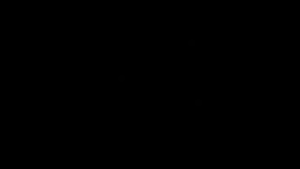


Example: data/masks2/cam2_080426_221845.png (720, 1280)


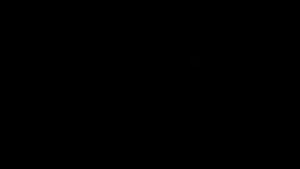

In [ ]:
# Sélectionner les lignes où 'center_point' n'est pas None et les masques ont probablement été créés
df_with_masks = df[df['center_point'].notna()]

sampled_masks = df_with_masks.sample(2)

print(f"Displaying {2} segmentation masks:")

# En supposant que 'mask_path' est déjà défini à partir de la cellule précédente
# Si 'mask_path' n'est pas défini, il peut être nécessaire de le redéfinir ici : mask_path = Path('data/masks/')

for index, row in sampled_masks.iterrows():
    nom_base = os.path.splitext(row.ID)[0]
    mask_filename = f"{nom_base}.png"
    # mask_filename = row['ID']
    mask_file_path = mask_path/mask_filename
    if mask_file_path.exists():
        im = PILImage.create(mask_file_path)
        print(f"\nExample: {mask_file_path} {im.shape}")
        display(im.to_thumb(300))
    else:
        print(f"Mask file not found for {mask_filename}")

### Dataloader `get` Functions

In [ ]:
def get_x(row):
    return row['image_path']

def get_mask(row):
    return row['mask_path']

### Create val, train and test data



In [32]:
# Sur 300 images :
# 220 (~73,3%) pour train
# 40 (~13,3%) pour val
# 40 (~13,3%) pour val

# Séparer les données de test
df_trainval, df_test = train_test_split(df, test_size=40, random_state=42, shuffle=True)

# Séparer les données d'entraînement et de validation
df_train, df_val = train_test_split(
    df_trainval,
    test_size=40,
    random_state=42,
    shuffle=True
)

# Créer les indices pour les données de validation pour avoir exactement 40 images
# Ne pas utiliser RandomSplitter car valid_pct = 0.13333... et c'est ambigu -> Soit 39 ou 41 images
df_trainval = pd.concat([df_train, df_val])
valid_idx = list(range(len(df_train), len(df_trainval))) # De l'indice 220 à 259 (40 images)

# Transformations
tfms = [
    Rotate(max_deg=10),
    Zoom(),
    # Warp(),
    Brightness(max_lighting=0.3),
    Flip(),
    Contrast(max_lighting=0.3),
    Normalize.from_stats(*imagenet_stats)
]

# Entraînement / Validation avec RandomSplitter
d_unet = DataBlock(blocks=(ImageBlock, MaskBlock),
                 get_x=get_x,
                 get_y=get_mask,
                 item_tfms=RandomCrop(512), # Reduced image size to save memory
                 splitter=IndexSplitter(valid_idx),
                 batch_tfms=tfms)

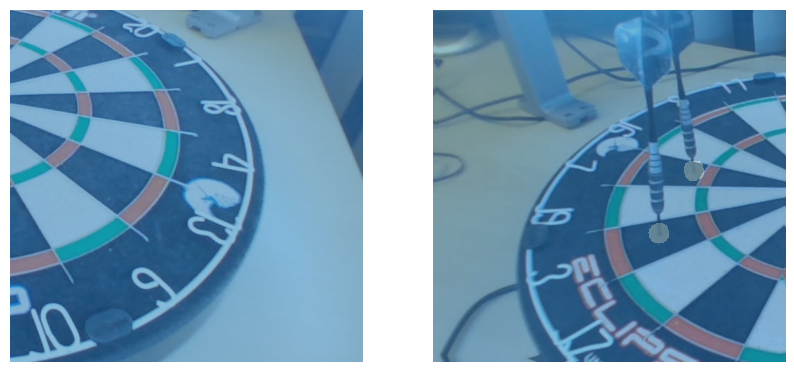

In [33]:
# La taille du lot est passée dans le dataloader
# Attention à l'overfitting et à l'utilisation excessive de la mémoire GPU
BATCH_SIZE = 2
# dls pour DataLoaders
dls = d_unet.dataloaders(df_trainval, bs=BATCH_SIZE)
dls.show_batch(max_n=2, figsize=(10,10))

### Inspection des masques car souvent on trouve pixel à 2 (normalement le masque doit être binaire)

In [34]:
import numpy as np
import cv2

# Prenez le chemin d'un ou plusieurs masques générés
chemin_test = df_trainval['mask_path'].iloc[5] # Adaptez selon votre dataframe
masque_test = cv2.imread(chemin_test, cv2.IMREAD_GRAYSCALE)

print("Valeurs uniques dans le masque :", np.unique(masque_test))
# Si ça affiche [0, 1, 2], le coupable est bien là !

Valeurs uniques dans le masque : [0 1]


### Create `UNet` Learner

In [35]:
learn = unet_learner(
    dls=dls,
    arch=resnet34,
    metrics=[DiceMulti, JaccardCoeffMulti], # metrics adaptés pour la segmentation binaire
    loss_func=FocalLossFlat(axis=1, gamma=3.39), # optuna results --- cette loss force le modèle à se concentrer sur les pixels rares car dataset déséquilibré
    self_attention=True,
    act_cls=Mish,
    pretrained=True,
    blur_final=True,
    opt_func=ranger,
    n_out=2
    ).to_fp16() # Activer l'entraînement en précision mixte pour réduire la consommation de mémoire GPU


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 112MB/s]


### Training Model

### Déterminer le meilleur pas d'apprentissage avec un LR finder

<div></div>

le bon pas d'apprentissage (lr) 0.00013182566908653826
CPU times: user 6min 15s, sys: 49.7 s, total: 7min 4s
Wall time: 20.8 s


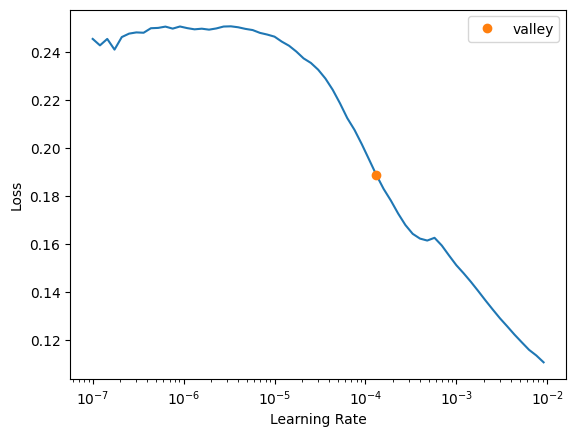

In [ ]:
%%time
# Résumé du modèle (architecture, couche, nb paramètres, ...)
# learn.summary()

# Détermine le bon learning_rate via un learning rate finder
# lr = learn.lr_find().valley
# print("le bon pas d'apprentissage (lr)",lr)

### Lancer l'entrainement

In [ ]:
# Lancer l'entraînement du modèle
lr = 0.00019741810806661364 # optuna results
wd = 0.0022799260228078 # optuna results
EPOCHS = 30

early_stopping_callback = EarlyStoppingCallback(monitor="jaccard_coeff_multi", patience=3)
checkpoint_callback = SaveModelCallback(
    monitor='jaccard_coeff_multi', comp=np.greater
)

# fit one cycle ajuste dynamiquement le taux d'apprentissage entre une valeur basse et maximale tout au long de l'entraînement
learn.fit_one_cycle(
    EPOCHS,
    slice(lr),
    pct_start=0.9, # 90% du temps d'entraînement à augmenter lr
    wd=wd,
    cbs=[
        early_stopping_callback,
        checkpoint_callback,
        WandbCallback()
    ]
)

epoch,train_loss,valid_loss,dice_multi,jaccard_coeff_multi,time
0,0.000386,0.000482,0.828993,0.744842,01:02
1,0.000362,0.000491,0.823899,0.739218,01:00
2,0.000397,0.000476,0.827523,0.743216,01:02
3,0.000340,0.000501,0.829213,0.745088,01:02
4,0.000369,0.000445,0.830905,0.746984,01:02
5,0.000333,0.000482,0.834764,0.751324,01:00
6,0.000317,0.000512,0.833224,0.749588,01:01
7,0.000320,0.000494,0.829069,0.744936,01:00


Better model found at epoch 0 with valid_loss value: 0.0004820181056857109.
Better model found at epoch 2 with valid_loss value: 0.00047638104297220707.
Better model found at epoch 4 with valid_loss value: 0.00044489078572951257.
No improvement since epoch 4: early stopping


### Fin de l'entrainement

In [ ]:
wandb.finish()

beta_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
beta_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
beta_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dice_multi,▄▁▃▄▆█▇▄
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇█
eps_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eps_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eps_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
jaccard_coeff_multi,▄▁▃▄▅█▇▄
lr_0,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
+15,...


### Enregistrer le modèle

In [ ]:
learn.save('dartsify_ai_optuna_dicejaccard_30epochs')
!cp "models/dartsify_ai_optuna_dicejaccard_30epochs.pth" "drive/My Drive/Dartsify/models/"

### Afficher les résultats de prédiction

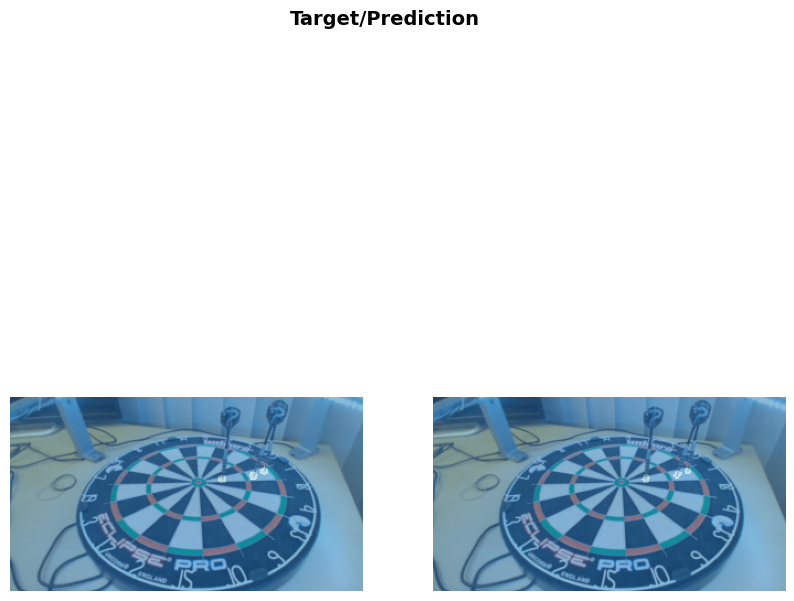

In [ ]:
learn.show_results(ds_idx=1, max_n=10, figsize=(10,10))

### Tester le modèle exporté avec les données de test

In [36]:
learn = load_learner("drive/My Drive/Dartsify/models/dartsify_ai_final.pkl")


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [39]:
# NETTOYAGE CRITIQUE : On supprime les callbacks d'entraînement pour l'inférence
if WandbCallback in [type(cb) for cb in learn.cbs]:
    learn.remove_cb(WandbCallback)

if SaveModelCallback in [type(cb) for cb in learn.cbs]:
    learn.remove_cb(SaveModelCallback)

if EarlyStoppingCallback in [type(cb) for cb in learn.cbs]:
    learn.remove_cb(EarlyStoppingCallback)

Évaluation en cours sur le jeu de test...


Score Dice final (Test)    : 0.9334
Score Jaccard final (Test) : 0.8822

Affichage d'un échantillon des prédictions :


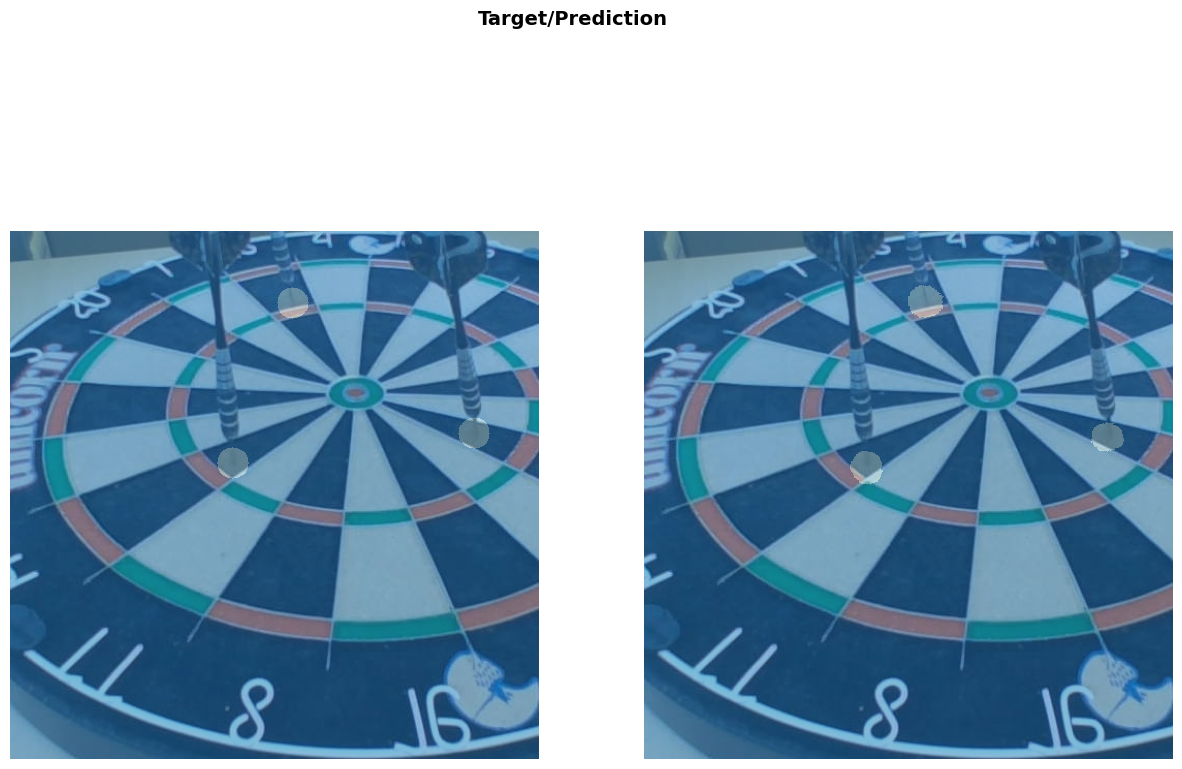

In [54]:
# Création du DataLoader de test à partir de votre df_test
dl_test = learn.dls.test_dl(df_test, with_labels=True)

print("Évaluation en cours sur le jeu de test...")
resultats_test = learn.validate(dl=dl_test)

# Index 0 = Loss (FocalLoss)
# Index 1 = DiceMulti
# Index 2 = JaccardCoeffMulti (IoU)
print(f"Score Dice final (Test)    : {resultats_test[1]:.4f}")
print(f"Score Jaccard final (Test) : {resultats_test[2]:.4f}")

# 3. Évaluation visuelle (Comparaison : Vrai masque | Prédiction de l'IA)
print("\nAffichage d'un échantillon des prédictions :")
learn.show_results(dl=dl_test, max_n=4, figsize=(15, 10))

In [51]:
preds, _ = learn.get_preds()

In [53]:
print(preds)

None


In [49]:
# Example Unet prediction mask

plt.figure(figsize = (10, 10))
plt.imshow(preds[0].numpy()[0])

TypeError: 'NoneType' object is not subscriptable

<Figure size 1000x1000 with 0 Axes>

### Visualisation des résultats + affichage masque

In [ ]:
# Convert prediction to cv2 image
n = 0
img = preds[n].numpy()[0] * 256
orig_img = img.copy()

# Convert the grayscale image to binary image
retval, thresh = cv2.threshold(img, 180, 255, 0)
thresh = cv2.convertScaleAbs(thresh)

# Find contours in the binary image
contours = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(contours)

for c in contours[1:]:
    # Calculate moments for each contour
    M = cv2.moments(c)
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    print("Centroid located:", (cX, cY))

    # Transparency layer
    overlay = img.copy()
    output = img.copy()
    clr = 0
    cv2.circle(overlay, (cX, cY), 25, (clr, clr, clr), -1)
    alpha = 0.4
    cv2.addWeighted(overlay, alpha, output, 1 - alpha,0, output)

    # Dart point
    cv2.circle(output, (cX, cY), 25, (clr, clr, clr), 1)
    cv2.circle(output, (cX, cY), 4, (clr, clr, clr), 1)
    cv2.putText(output, f"{(cX, cY)}", (cX - 105, cY - 30), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (clr, clr, clr), 1, cv2.LINE_AA)

val_img = dls.valid_ds[n][0]
val_img = cv2.cvtColor(np.array(val_img), cv2.COLOR_RGB2BGR)
val_img = val_img[:, :, ::-1].copy()

fig, ax = plt.subplots(1, 3)
ax[0].imshow(val_img), ax[1].imshow(orig_img), ax[2].imshow(output)
fig.set_size_inches(20, 5)
plt.tight_layout()

### Dessiner la pointe avec un overlay transparent

In [ ]:
pil_image = dls.valid_ds[n][0]
img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
img = img[:, :, ::-1].copy()

# Transparency layer
overlay = img.copy()
output = img.copy()
inner_colour = (255, 255, 255)
outer_colour = (255, 255, 255)
cv2.circle(overlay, (cX, cY), 25, outer_colour, -1)
alpha = 0.2
cv2.addWeighted(overlay, alpha, output, 1 - alpha,0, output)

# Dart point
cv2.circle(output, (cX, cY), 25, outer_colour, 1, cv2.LINE_AA)
cv2.circle(output, (cX, cY), 3, inner_colour, 1, cv2.LINE_AA)
cv2.putText(output, f"{(cX, cY)}", (cX - 105, cY - 30), cv2.FONT_HERSHEY_SIMPLEX,
            0.5, inner_colour, 1, cv2.LINE_AA)

plt.figure(figsize = (14, 14))
plt.imshow(output)
#plt.tight_layout()
plt.show()

In [ ]:
%%time
n = random.randint(0,90)
#n = 18
print('  Validation set:', n)

img = preds[n].numpy()[0] * 256
orig_img = img.copy()

# Convert the grayscale image to binary image
retval, thresh = cv2.threshold(img, 180, 255, 0)
thresh = cv2.convertScaleAbs(thresh)

# Find contours in the binary image
contours = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(contours)

for c in contours[1:]:
    # Calculate moments for each contour
    M = cv2.moments(c)
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    print("Centroid located:", (cX, cY))

    pil_image = dls.valid_ds[n][0]
    img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    img = img[:, :, ::-1].copy()

    # Transparency layer
    overlay = img.copy()
    output = img.copy()
    inner_colour = (255, 255, 255)
    outer_colour = (255, 255, 255)
    cv2.circle(overlay, (cX, cY), 25, outer_colour, -1)
    alpha = 0.2
    cv2.addWeighted(overlay, alpha, output, 1 - alpha,0, output)

    # Dart point
    cv2.circle(output, (cX, cY), 25, outer_colour, 1, cv2.LINE_AA)
    cv2.circle(output, (cX, cY), 3, inner_colour, 1, cv2.LINE_AA)
    cv2.putText(output, f"{(cX, cY)}", (cX - 105, cY - 30), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, inner_colour, 1, cv2.LINE_AA)

plt.figure(figsize = (14, 14))
plt.imshow(output)
#plt.tight_layout()
plt.show()

### Exporter/Importer le modèle


In [ ]:
learn.export("dartsify_ai_final_30epochs.pkl")

In [ ]:
%cp dartsify_ai_final_30epochs.pkl "drive/My Drive/Dartsify/models/dartsify_ai_final_30epochs.pkl"

### Code d'inférence pour charger et tester le modèle

In [ ]:
learn_inf = load_learner("drive/My Drive/Dartsify/models/dartsify_ai_final_30epochs.pkl")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


### Debug : Vérifier s'il arrive à trouver les pointes de la fléchette avec toutes les images du dataset

In [ ]:
import glob

In [ ]:
%%time
for i in glob.glob("drive/My Drive/Dartsify/dataset/*"):
  out = learn_inf.predict(i)
  if out[0].numpy().sum() > 0:
    print(i)
    break


In [ ]:
path_image = 'data/dataset/cam1_080426_215714.jpg'

In [ ]:
# NETTOYAGE CRITIQUE : On supprime les callbacks d'entraînement pour l'inférence
if WandbCallback in [type(cb) for cb in learn_inf.cbs]:
    learn_inf.remove_cb(WandbCallback)

if SaveModelCallback in [type(cb) for cb in learn_inf.cbs]:
    learn_inf.remove_cb(SaveModelCallback)

In [ ]:
out = learn_inf.predict(path_image)
print(out[0].numpy().sum())

KeyboardInterrupt: 

La fléchètte se trouve en : (173, 93)
La fléchètte se trouve en : (141, 65)


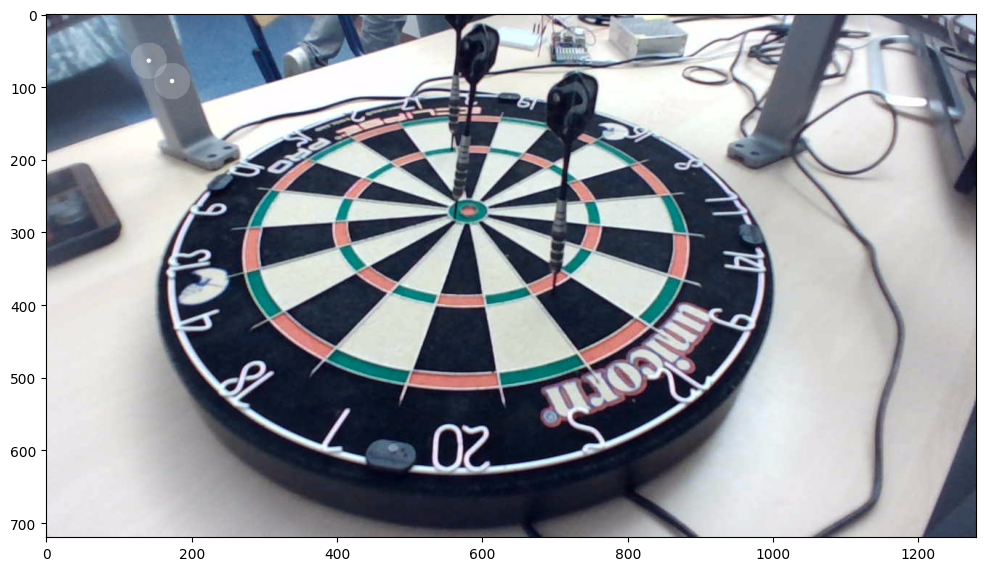

CPU times: user 254 ms, sys: 11.3 ms, total: 265 ms
Wall time: 257 ms


In [ ]:
%%time
pil_image = PILImage.create(path_image)
image_np = np.array(pil_image) # Convert PILImage to NumPy array (RGB format)
image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR) # Convert RGB to BGR for OpenCV

mask = out[0].numpy()

# garder seulement la classe "Point"
mask = (mask == 1).astype(np.uint8) * 255
"""
Etape post-traitement de l'image de sortie du modèle pour trouver les coordonnées de la fléchette
et les afficher sur l'image d'origine
"""
mask = cv2.convertScaleAbs(mask)

# trouver les contours de la fléchette
contours = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(contours)

output = image_bgr.copy() # Use the BGR NumPy array for output

for c in contours:
    M = cv2.moments(c)

    if M["m00"] == 0: # Avoid division by zero if moment is 0
        continue

    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    print("La fléchètte se trouve en :", (cX, cY))

    overlay = output.copy() # overlay is now a NumPy array

    color = (255, 255, 255) # BGR white
    cv2.circle(overlay, (cX, cY), 25, color, -1)

    alpha = 0.2
    cv2.addWeighted(overlay, alpha, output, 1 - alpha,0, output)

    cv2.circle(output, (cX, cY), 3, color, -1)

plt.figure(figsize = (12, 12))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)) # Convert BGR back to RGB for display
plt.show()

### FINE TUNE

In [ ]:
# On réutilise les hyperparamètres d'Optuna
BEST_GAMMA = 3.39
BEST_WD = 0.0022799260228078
BEST_LR = 0.00019741810806661364

checkpoint = SaveModelCallback(monitor='jaccard_coeff_multi', comp=np.greater) # On allonge l'entrainement en évitant le surapprentissage
early_stopping = EarlyStoppingCallback(monitor="jaccard_coeff_multi", patience=3)

learn = unet_learner(
    dls=dls,
    arch=resnet34, # <-- On passe au ResNet34
    metrics=[DiceMulti(), JaccardCoeffMulti()],
    loss_func=FocalLossFlat(axis=1, gamma=BEST_GAMMA),
    wd=BEST_WD,
    self_attention=True,
    act_cls=Mish,
    pretrained=True,
    blur_final=True,
    opt_func=ranger,
    n_out=2,
    cbs=[checkpoint, early_stopping, WandbCallback()]
).to_fp16()

# On laisse le modèle s'entraîner longtemps !
learn.fine_tune(30, base_lr=BEST_LR)

epoch,train_loss,valid_loss,dice_multi,jaccard_coeff_multi,time
0,0.002601,0.001756,0.811521,0.725257,04:00


Better model found at epoch 0 with jaccard_coeff_multi value: 0.7252572771602604.


epoch,train_loss,valid_loss,dice_multi,jaccard_coeff_multi,time
0,0.001143,0.001423,0.844619,0.762042,04:21
1,0.001054,0.001096,0.854080,0.773439,04:17
2,0.000900,0.000888,0.885164,0.812754,04:20
3,0.000836,0.000975,0.883116,0.809962,04:23
4,0.000800,0.000867,0.897167,0.829033,04:24
5,0.000654,0.000820,0.898474,0.830852,04:21
6,0.000637,0.000830,0.897791,0.829913,04:22
7,0.000752,0.000634,0.916552,0.856708,04:19
8,0.000687,0.000619,0.918636,0.859790,04:19
9,0.000648,0.000686,0.906360,0.841954,04:22


Better model found at epoch 0 with jaccard_coeff_multi value: 0.7620424913852789.
Better model found at epoch 1 with jaccard_coeff_multi value: 0.7734388740471605.
Better model found at epoch 2 with jaccard_coeff_multi value: 0.8127537989889042.
Better model found at epoch 4 with jaccard_coeff_multi value: 0.8290330441728347.
Better model found at epoch 5 with jaccard_coeff_multi value: 0.8308520184329655.
Better model found at epoch 7 with jaccard_coeff_multi value: 0.8567078455094975.
Better model found at epoch 8 with jaccard_coeff_multi value: 0.8597900747876188.
Better model found at epoch 10 with jaccard_coeff_multi value: 0.8670344133329357.
Better model found at epoch 11 with jaccard_coeff_multi value: 0.8797938550499393.
Better model found at epoch 12 with jaccard_coeff_multi value: 0.8915674577306767.
Better model found at epoch 14 with jaccard_coeff_multi value: 0.8942865758752605.
Better model found at epoch 15 with jaccard_coeff_multi value: 0.8998367142695263.
No improvem

In [ ]:
wandb.finish()

beta_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
beta_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
beta_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dice_multi,▁▃▃▅▅▆▆▆▇▇▆▇▇███████
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
eps_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eps_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eps_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
jaccard_coeff_multi,▁▂▃▅▄▅▅▅▆▆▆▇▇███████
lr_0,█▁▁▁▁▁▁▂▂▂▃▄▄▄▅▅▆▆▆▆▇█████▇▇▇▇▇▇▇▇▆▆▆▆▆▄
+15,...


In [ ]:
learn.export("dartsify_ai_final.pkl")

In [ ]:
%cp dartsify_ai_final.pkl "drive/My Drive/Dartsify/models/dartsify_ai_final.pkl"

### OPTUNA

In [ ]:
!pip install optuna "optuna-integration[fastai]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 145.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.1/615.1 kB 58.0 MB/s eta 0:00:00


In [ ]:
import optuna
from optuna.integration import FastAIPruningCallback
import gc
import torch
from fastai.vision.all import *

In [ ]:
def objective(trial):
    # ---------------------------------------------------------
    # 1. DÉFINITION DES HYPERPARAMÈTRES À TESTER
    # ---------------------------------------------------------
    # Optuna va chercher le meilleur Learning Rate (échelle logarithmique)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    # Recherche du Weight Decay (pénalité pour éviter le surapprentissage)
    wd = trial.suggest_float("wd", 1e-6, 1e-2, log=True)

    gamma_val = trial.suggest_float("gamma", 1.5, 4.0)

    # --- LE CALLBACK DE PRUNING ---
    # Il va surveiller la 'valid_loss' à chaque époque.
    pruning_cb = FastAIPruningCallback(trial, monitor='valid_loss')

    # ---------------------------------------------------------
    # 2. INITIALISATION DES DONNÉES ET DU MODÈLE
    # ---------------------------------------------------------
    local_batch_size = 1 # Using BATCH_SIZE=1 as established to avoid OOM
    dls = d_unet.dataloaders(df_trainval, bs=local_batch_size) # Create dls locally for the objective function

    learn = unet_learner(
        dls=dls,
        arch=resnet18,
        metrics=[DiceMulti, JaccardCoeffMulti],
        loss_func=FocalLossFlat(axis=1,gamma=gamma_val), # Changed to BCEWithLogitsFlat for binary segmentation
        wd=wd,
        self_attention=True,
        act_cls=Mish,
        pretrained=True,
        blur_final=True,
        opt_func=ranger,
        n_out=2
    ).to_fp16()

    # ---------------------------------------------------------
    # 3. ENTRAÎNEMENT
    # ---------------------------------------------------------
    with learn.no_bar(), learn.no_logging():
        learn.fine_tune(3, base_lr=lr)

    # ---------------------------------------------------------
    # 4. RÉCUPÉRATION DU SCORE
    # ---------------------------------------------------------
    val_results = learn.validate()
    jaccard_score = val_results[2]

    # ---------------------------------------------------------
    # 5. NETTOYAGE ABSOLU DE LA MÉMOIRE (CRITIQUE)
    # ---------------------------------------------------------
    del learn
    del dls
    torch.cuda.empty_cache()
    gc.collect()

    # Optuna va essayer de maximiser cette valeur !
    return jaccard_score

In [ ]:
# On indique à Optuna qu'on veut MAXIMISER le score retourné (le Jaccard)
# Configuration de l'élagueur
# n_warmup_steps=1 : On laisse au moins 1 époque se terminer avant de juger si c'est mauvais.
study = optuna.create_study(
    direction="maximize",
    study_name="Dartsify_UNet_Optimization",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
    )

# On lance l'optimisation pour 8 essais (à ajuster selon votre temps/GPU)
study.optimize(objective, n_trials=8)

# Afficher les meilleurs résultats à la fin
print("Meilleur score Jaccard atteint :", study.best_value)
print("Meilleurs hyperparamètres :", study.best_params)

[I 2026-04-21 03:16:54,320] A new study created in memory with name: Dartsify_UNet_Optimization


[I 2026-04-21 03:20:59,375] Trial 0 finished with value: 0.6150704928278533 and parameters: {'lr': 0.00018485132313701767, 'wd': 1.4328156630451553e-05, 'gamma': 3.4438021662781977}. Best is trial 0 with value: 0.6150704928278533.


[I 2026-04-21 03:25:14,370] Trial 1 finished with value: 0.621548589056712 and parameters: {'lr': 0.0003048800761204628, 'wd': 1.8081140099681974e-06, 'gamma': 3.6635414637171677}. Best is trial 1 with value: 0.621548589056712.


[I 2026-04-21 03:29:26,293] Trial 2 finished with value: 0.552652786216398 and parameters: {'lr': 0.00011373420509227753, 'wd': 0.002691189808461162, 'gamma': 3.782296686142181}. Best is trial 1 with value: 0.621548589056712.


[I 2026-04-21 03:33:36,289] Trial 3 finished with value: 0.5108152010077077 and parameters: {'lr': 3.311682189762034e-05, 'wd': 2.33814654641259e-05, 'gamma': 1.7170433840717085}. Best is trial 1 with value: 0.621548589056712.


[I 2026-04-21 03:37:50,754] Trial 4 finished with value: 0.5548313696337351 and parameters: {'lr': 9.860689397449191e-05, 'wd': 1.629112100415572e-06, 'gamma': 2.4935737371771003}. Best is trial 1 with value: 0.621548589056712.


[I 2026-04-21 03:42:04,030] Trial 5 finished with value: 0.6247871575285338 and parameters: {'lr': 0.00019741810806661364, 'wd': 0.0022799260228078, 'gamma': 3.3987964146829057}. Best is trial 5 with value: 0.6247871575285338.


[I 2026-04-21 03:46:10,948] Trial 6 finished with value: 0.5015022325415229 and parameters: {'lr': 2.1359638434460616e-05, 'wd': 0.0058549922176915755, 'gamma': 1.9192120858349}. Best is trial 5 with value: 0.6247871575285338.


[I 2026-04-21 03:50:21,834] Trial 7 finished with value: 0.5653255481348182 and parameters: {'lr': 0.00011047045800237403, 'wd': 6.850374310271641e-06, 'gamma': 2.1689814318650678}. Best is trial 5 with value: 0.6247871575285338.


Meilleur score Jaccard atteint : 0.6247871575285338
Meilleurs hyperparamètres : {'lr': 0.00019741810806661364, 'wd': 0.0022799260228078, 'gamma': 3.3987964146829057}
